<a href="https://colab.research.google.com/github/Manjushreetr/Manjushree_Labmentix/blob/Amazon-Prime-EDA/Flipkart_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Flipkart EDA**


##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Team Member -** - Manjushree T R


# **Project Summary -**

The project analyzes customer satisfaction (CSAT) scores in relation to various factors such as response time, issue categories, and agent shifts to identify improvement opportunities. Key insights guide strategies to optimize response times, improve agent performance, and enhance customer service quality.

# **GitHub Link -**

https://github.com/Manjushreetr/Manjushree_Labmentix/blob/Flipkart_EDA/Flipkart_EDA.ipynb

# **Problem Statement**


Understanding factors that influence customer satisfaction.
Resolve customer issues faster.
Support strategies to meet diverse customer expectations.
Optimizing the performance of service agents and improving satisfaction metrics like the CSAT score.

#### **Define Your Business Objective?**

# **EDA Analysis**


## ***1. Know Your Data***

#### Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import random
from wordcloud import WordCloud

### Preprocessing
#### Exploring data

In [3]:
df= pd.read_csv(r'/content/Customer_support_data.csv', encoding='utf-8')

In [4]:
df.shape

(9336, 20)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9336 entries, 0 to 9335
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                9336 non-null   object 
 1   channel_name             9336 non-null   object 
 2   category                 9336 non-null   object 
 3   Sub-category             9336 non-null   object 
 4   Customer Remarks         3054 non-null   object 
 5   Order_id                 5119 non-null   object 
 6   order_date_time          1504 non-null   object 
 7   Issue_reported at        9336 non-null   object 
 8   issue_responded          9336 non-null   object 
 9   Survey_response_Date     9336 non-null   object 
 10  Customer_City            1491 non-null   object 
 11  Product_category         1503 non-null   object 
 12  Item_price               1504 non-null   float64
 13  connected_handling_time  4 non-null      float64
 14  Agent_name              

In [6]:
df['Unique id'].nunique()

9336

In [7]:
df.head()

/usr/local/lib/python3.11/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01-08-2023 11:13,01-08-2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5.0
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01-08-2023 12:52,01-08-2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5.0
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01-08-2023 20:16,01-08-2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5.0
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01-08-2023 20:56,01-08-2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5.0
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01-08-2023 10:30,01-08-2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5.0


## ***2. Understanding Your Variables***

In [8]:
duplicate_df= df[df.duplicated(subset=['Unique id'], keep=False)]

In [9]:
duplicate_df

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score


1. Unique id - This variable does not contain any duplicate values, making it suitable to be considered as the primary key.
2. channel_name - We can observe that the number of ways through whcih the product sells.
3. category - This variable contains all the procedure which takes place in flipkart.
4. Sub-category- This variable narrows down the category field, this is usefull to create the visual.  
5. Customer Remarks- There are many null field, we can consider this variable while creating charts.
6. Order_id - There are many null field, we can consider this variable while creating charts.  
7. order_date_time - There are many null field, we can ignore this variable while creating charts.
8. Issue_reported at - This variable can be considered, this is usefull to create the visual.  
9. issue_responded - This variable can be considered, this is usefull to create the visual.  
10. Survey_response_Date - This variable can be considered, this is usefull to create the visual.  
11. Customer_City-  There are many null field, we can consider this variable while creating charts.
12. Product_category- This variable contains all the category of product in flipkart.
13. Item_price- There are many null field, we can ignore this variable while creating charts.
14. connected_handling_time- There are many null field, we can ignore this variable while creating charts.
15. Agent_name- We can ignore this variable while creating charts.
16. Supervisor- We can ignore this variable while creating charts.
17. Manager- We can ignore this variable while creating charts.
18. Tenure Bucket- We can ignore this variable while creating charts.
19. Agent Shift- We can ignore this variable while creating charts.
20. CSAT Score- This variable can be considered, this is usefull to create the visual.  

## ***3. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***


#### Chart - 1 - CSAT Score vs Channel Name

In [10]:
df_channelcsat=df.groupby('channel_name')['CSAT Score'].mean().reset_index()

In [11]:
df_channelcsat

,channel_name,CSAT Score
0,Email,3.790614
1,Inbound,4.210519
2,Outcall,4.182136


<ipython-input-12-cbdf8e68efa6>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= df_channelcsat, x='channel_name', y='CSAT Score', palette='viridis')


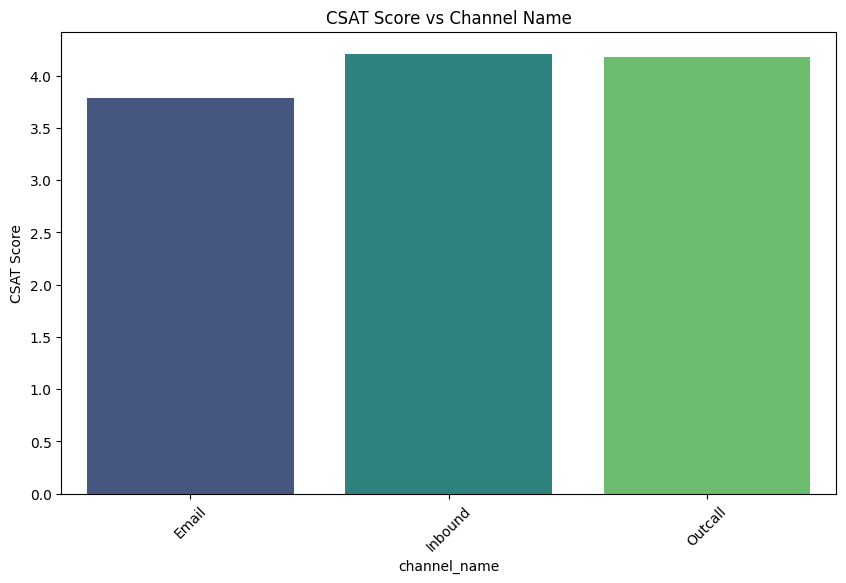

In [12]:
plt.figure(figsize=(10, 6))
sns.barplot(data= df_channelcsat, x='channel_name', y='CSAT Score', palette='viridis')

plt.xlabel("channel_name")
plt.ylabel("CSAT Score")
plt.title("CSAT Score vs Channel Name")
plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart helps in comparing the Channels, as it visually represents variations of average CSAT Score by Channels.

##### 2. What is/are the insight(s) found from the chart?

We observed that Flipkart has three channels, with Inbound and Outcall being the top-performing channels in terms of CSAT scores.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

We observed that the Email channel has the lowest score. We need to understand why customers are not satisfied with the service provided through this channel.

#### Chart - 2 - Bottom 10 Sub category by CSAT score

In [13]:
df_subcategory=df.groupby('Sub-category')['CSAT Score'].mean().reset_index()

In [14]:
df_subcategory_bottom10=df_subcategory.sort_values('CSAT Score').head(10)

In [15]:
df_subcategory_bottom10

,Sub-category,CSAT Score
45,Unable to Login,1.000000
26,Others,1.000000
5,Call back request,2.500000
48,Warranty related,2.833333
37,Seller Cancelled Order,3.134078
43,Technician Visit,3.274194
6,Call disconnected,3.285714
50,e-Gift Voucher,3.333333
41,Shopzilla Rewards,3.500000
0,Account updation,3.529412


<ipython-input-16-7a469dcb136d>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= df_subcategory_bottom10, x='Sub-category', y='CSAT Score', palette='viridis')


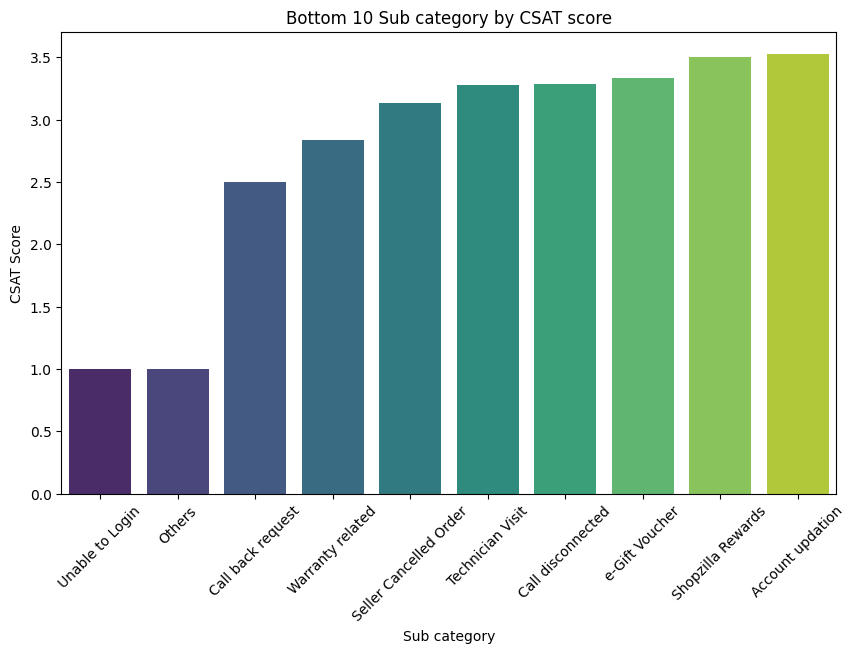

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(data= df_subcategory_bottom10, x='Sub-category', y='CSAT Score', palette='viridis')

plt.xlabel("Sub category")
plt.ylabel("CSAT Score")
plt.title("Bottom 10 Sub category by CSAT score")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart helps in comparing the Sub category, as it visually represents variations of average CSAT Score by Sub category.

##### 2. What is/are the insight(s) found from the chart?

We observed that there are many sub category, most of the sub category have more than 3.5 Csat score. The bottom sub category in terms of CSAT scores are Commission Related, Unable to Login and Service Center - Service Deniel.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

We observed that the bottom sub category in terms of CSAT scores are Commission Related, Unable to Login and Service Center - Service Deniel. We need to understand why customers are not satisfied with the service provided through this channel.

#### Chart - 3 - Bottom 10 Agent name by CSAT score

In [17]:
df_Agentname=df.groupby('Agent_name')['CSAT Score'].mean().reset_index()

In [18]:
df_Agentname

,Agent_name,CSAT Score
0,Aaron Edwards,4.285714
1,Adam Barnett,4.000000
2,Adam Hammond,4.583333
3,Adam Hernandez,4.727273
4,Adam Torres,4.000000
...,...,...
1123,Willie Flores,3.000000
1124,Yesenia Bowers,4.000000
1125,Zachary Ford,4.200000
1126,Zachary Reyes,4.000000


In [19]:
df_Agentname_Bottom10=df_Agentname.sort_values('CSAT Score').head(10)

<ipython-input-20-b8240dd5e8af>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= df_Agentname_Bottom10, x='Agent_name', y='CSAT Score', palette='viridis')


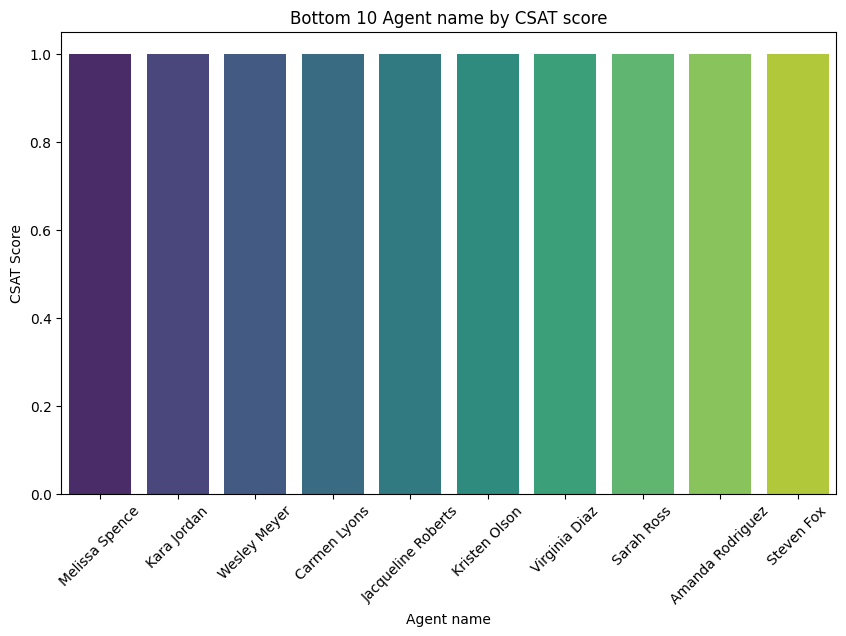

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(data= df_Agentname_Bottom10, x='Agent_name', y='CSAT Score', palette='viridis')

plt.xlabel("Agent name")
plt.ylabel("CSAT Score")
plt.title("Bottom 10 Agent name by CSAT score")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart helps in comparing the Agent name, as it visually represents variations of average CSAT Score by Agent name.


##### 2. What is/are the insight(s) found from the chart?

We observed that bottom 10 agents are below 2.5, rest all are ahving more than 2.5 CSAT score.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

We observed that the Philip Harmon has the lowest score. We need to understand why customers are not satisfied with the service provided through this agent.

#### Chart - 4 - Bottom 10 Supervisor by CSAT score

In [21]:
df_Supervisor=df.groupby('Supervisor')['CSAT Score'].mean().reset_index()

In [22]:
df_Supervisor_bottom10=df_Supervisor.sort_values('CSAT Score').head(10)

In [23]:
df_Supervisor_bottom10

,Supervisor,CSAT Score
31,Oliver Nguyen,3.254902
4,Austin Johnson,3.754902
26,Mason Gupta,3.937500
8,Charlotte Suzuki,3.946429
19,Jacob Sato,3.957265
16,Harper Wong,3.978417
12,Emma Park,3.979849
38,Zoe Yamamoto,4.005764
5,Ava Wong,4.015789
18,Jackson Park,4.021661


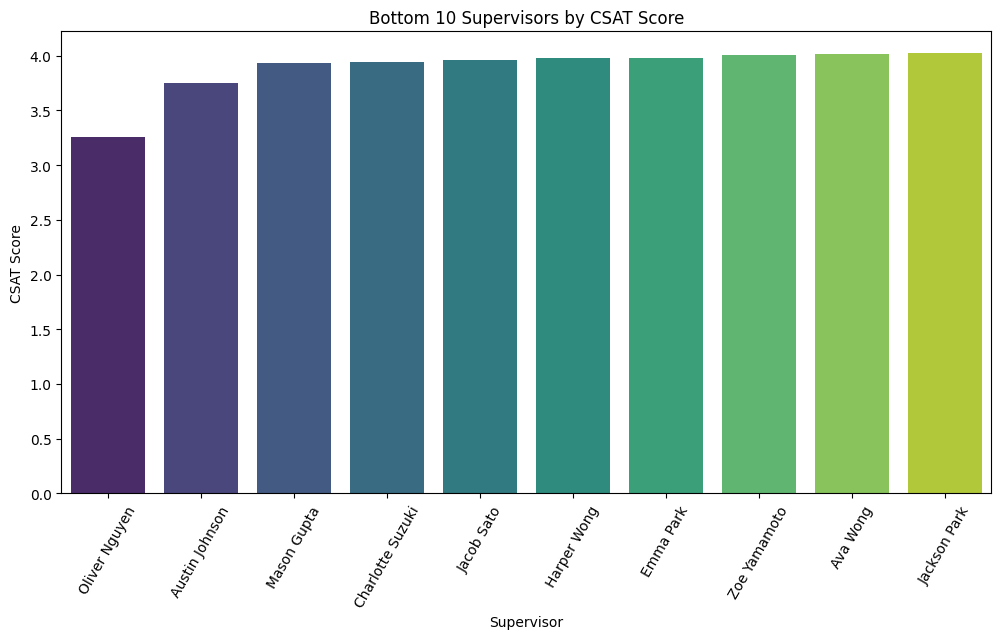

In [24]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_Supervisor_bottom10, x='Supervisor', y='CSAT Score', hue='Supervisor', palette='viridis', legend=False)

plt.xlabel("Supervisor")
plt.ylabel("CSAT Score")
plt.title("Bottom 10 Supervisors by CSAT Score")
plt.xticks(rotation=60)
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart helps in comparing the Supervisor, as it visually represents variations of average CSAT Score.


##### 2. What is/are the insight(s) found from the chart?

We observed that Oliver Nguyenb has the lowest CSAT score.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

We observed that only one Supervisor has a CSAT Score below 4, while the rest have scores above 4. This indicates that only one Supervisor needs significant improvement, whereas the others can focus on refining their performance to achieve even better results.

#### Chart - 5 - Bottom Manager by CSAT score

In [25]:
df_Manager=df.groupby('Manager')['CSAT Score'].mean().reset_index()

In [26]:
df_Manager_bottom=df_Manager.sort_values('CSAT Score').head(10)

In [27]:
df_Manager_bottom

,Manager,CSAT Score
5,William Kim,3.915743
1,Jennifer Nguyen,3.925570
4,Olivia Tan,4.027451
2,John Smith,4.201430
3,Michael Lee,4.202634
0,Emily Chen,4.350911


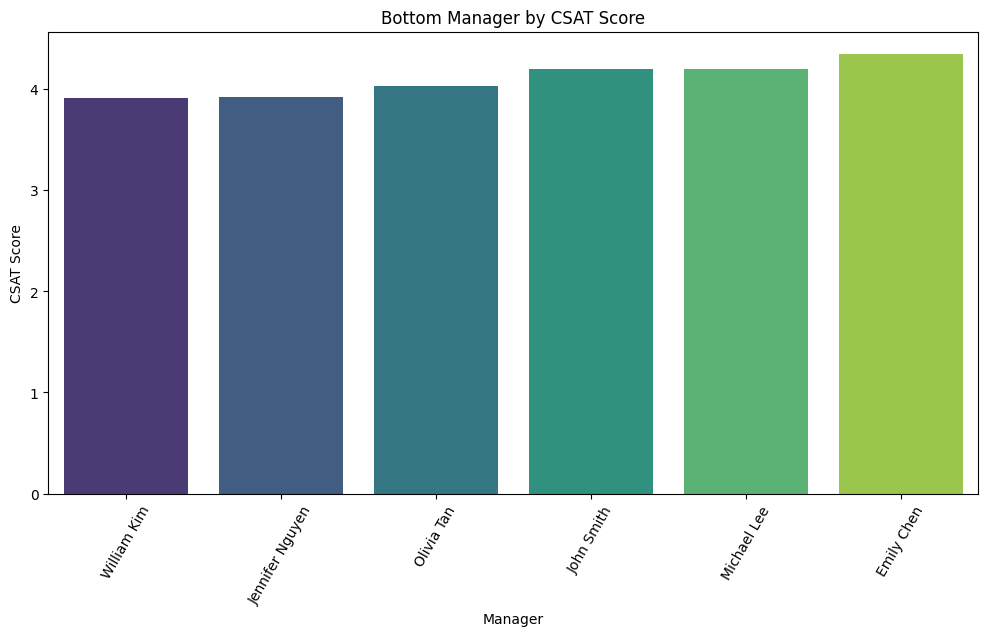

In [28]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_Manager_bottom, x='Manager', y='CSAT Score', hue='Manager', palette='viridis', legend=False)

plt.xlabel("Manager")
plt.ylabel("CSAT Score")
plt.title("Bottom Manager by CSAT Score")
plt.xticks(rotation=60)
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart helps in comparing the Manager, as it visually represents variations of average CSAT Score.

##### 2. What is/are the insight(s) found from the chart?

We observed that Manager Oliver Tan has the lowest CSAT score.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

We observed that all the mangers has a CSAT Score inbetween 4 to 4.3. This indicates that all managers need significant improvement.

#### Chart - 6 - Bottom 10 Issue Responded by CSAT Score

In [29]:
df['issue_responded_new'] = pd.to_datetime(df['issue_responded'], format="%d-%m-%Y %H:%M", errors='coerce')

In [30]:
df['issue_responded_new']

,issue_responded_new
0,2023-08-01 11:47:00
1,2023-08-01 12:54:00
2,2023-08-01 20:38:00
3,2023-08-01 21:16:00
4,2023-08-01 10:32:00
...,...
9331,2023-08-04 17:58:00
9332,2023-08-04 11:33:00
9333,2023-08-04 20:49:00
9334,2023-08-04 22:48:00


In [31]:
df_issue_responded_new=df.groupby(df['issue_responded_new'])['CSAT Score'].mean().reset_index()

In [32]:
df_issue_responded_bottom10=df_issue_responded_new.sort_values('CSAT Score').head(10)

In [33]:
df_issue_responded_bottom10

,issue_responded_new,CSAT Score
3950,2023-08-05 02:54:00,1.0
612,2023-08-01 17:31:00,1.0
2790,2023-08-03 20:53:00,1.0
607,2023-08-01 17:26:00,1.0
2818,2023-08-03 21:24:00,1.0
599,2023-08-01 17:17:00,1.0
593,2023-08-01 17:10:00,1.0
2830,2023-08-03 21:37:00,1.0
2833,2023-08-03 21:40:00,1.0
2842,2023-08-03 21:51:00,1.0


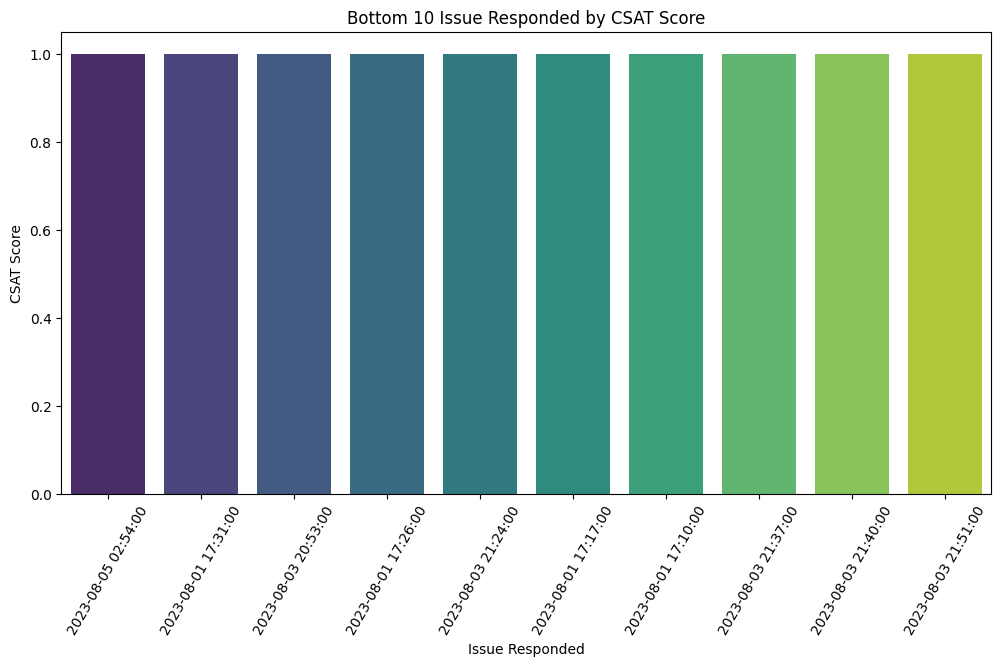

In [34]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_issue_responded_bottom10, x='issue_responded_new', y='CSAT Score', hue='issue_responded_new', palette='viridis', legend=False)

plt.xlabel("Issue Responded")
plt.ylabel("CSAT Score")
plt.title("Bottom 10 Issue Responded by CSAT Score")
plt.xticks(rotation=60)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart helps to compare the dates where there were gaps in issue response times.

##### 2. What is/are the insight(s) found from the chart?

We observed that on many dates, the issue response was unsatisfactory to customers, as reflected in the CSAT score.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Due to the unsatisfactory response from Flipkart, customers provided a score of less than 2, indicating their dissatisfaction.

#### Chart - 7 - Scatter Plot: Time Difference vs. CSAT Score

In [35]:
df['Issue_reported at'] = pd.to_datetime(df['Issue_reported at'], format="%d-%m-%Y %H:%M", errors='coerce')

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9336 entries, 0 to 9335
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Unique id                9336 non-null   object        
 1   channel_name             9336 non-null   object        
 2   category                 9336 non-null   object        
 3   Sub-category             9336 non-null   object        
 4   Customer Remarks         3054 non-null   object        
 5   Order_id                 5119 non-null   object        
 6   order_date_time          1504 non-null   object        
 7   Issue_reported at        9336 non-null   datetime64[ns]
 8   issue_responded          9336 non-null   object        
 9   Survey_response_Date     9336 non-null   object        
 10  Customer_City            1491 non-null   object        
 11  Product_category         1503 non-null   object        
 12  Item_price               1504 non-

In [37]:
df_Response_new = df["issue_responded_new"] - df["Issue_reported at"]

In [38]:
df_Response_new

,0
0,0 days 00:34:00
1,0 days 00:02:00
2,0 days 00:22:00
3,0 days 00:20:00
4,0 days 00:02:00
...,...
9331,0 days 00:04:00
9332,0 days 00:59:00
9333,0 days 00:05:00
9334,0 days 00:36:00


In [41]:
Response_values = df_Response_new.dt.total_seconds() / 3600

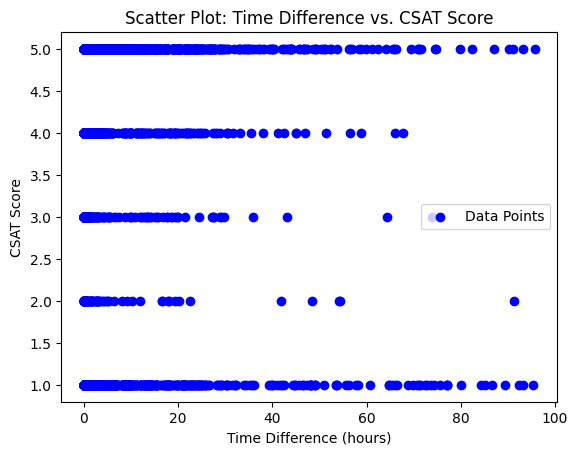

In [42]:
plt.scatter(Response_values, df['CSAT Score'], color='blue', label='Data Points')

plt.xlabel('Time Difference (hours)')
plt.ylabel('CSAT Score')
plt.title('Scatter Plot: Time Difference vs. CSAT Score')

plt.legend()

plt.show()

##### 1. Why did you pick the specific chart?

A scatter chart helps visualize the relationship between Time Difference (issue reported vs. issue responded).

##### 2. What is/are the insight(s) found from the chart?

If CSAT Scores decrease as response time increases, it suggests that delayed responses lead to lower customer satisfaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

A few cases have very high response times but good CSAT scores.
Some have quick responses but low CSAT scores, indicating issues beyond response speed.

#### Chart - 8 - CSAT Score Trend Over Time Difference

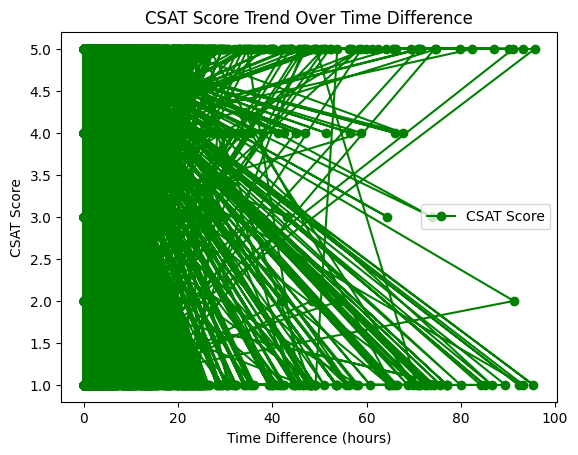

In [43]:
plt.plot(Response_values, df['CSAT Score'], marker='o', linestyle='-', color='green', label='CSAT Score')

plt.xlabel('Time Difference (hours)')
plt.ylabel('CSAT Score')
plt.title('CSAT Score Trend Over Time Difference')

plt.legend()
plt.show()

##### 1. Why did you pick the specific chart?

This chart helps analyze how customer satisfaction changes based on response time.

##### 2. What is/are the insight(s) found from the chart?

If CSAT Scores decrease as response time increases, it suggests that longer response times lead to lower customer satisfaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps identify an optimal response time range where CSAT Scores are highest.
Can be used to set service-level agreements (SLAs) for faster issue resolution.
If some cases show fast response but low CSAT, it might indicate poor resolution quality.
If some cases show slow response but high CSAT, it could mean issue complexity is a factor.

#### Chart - 9 - CSAT Score by Category & Sub-category

In [45]:
df_categorySub_grouped = df.groupby(['category', 'Sub-category'])['CSAT Score'].mean().unstack()

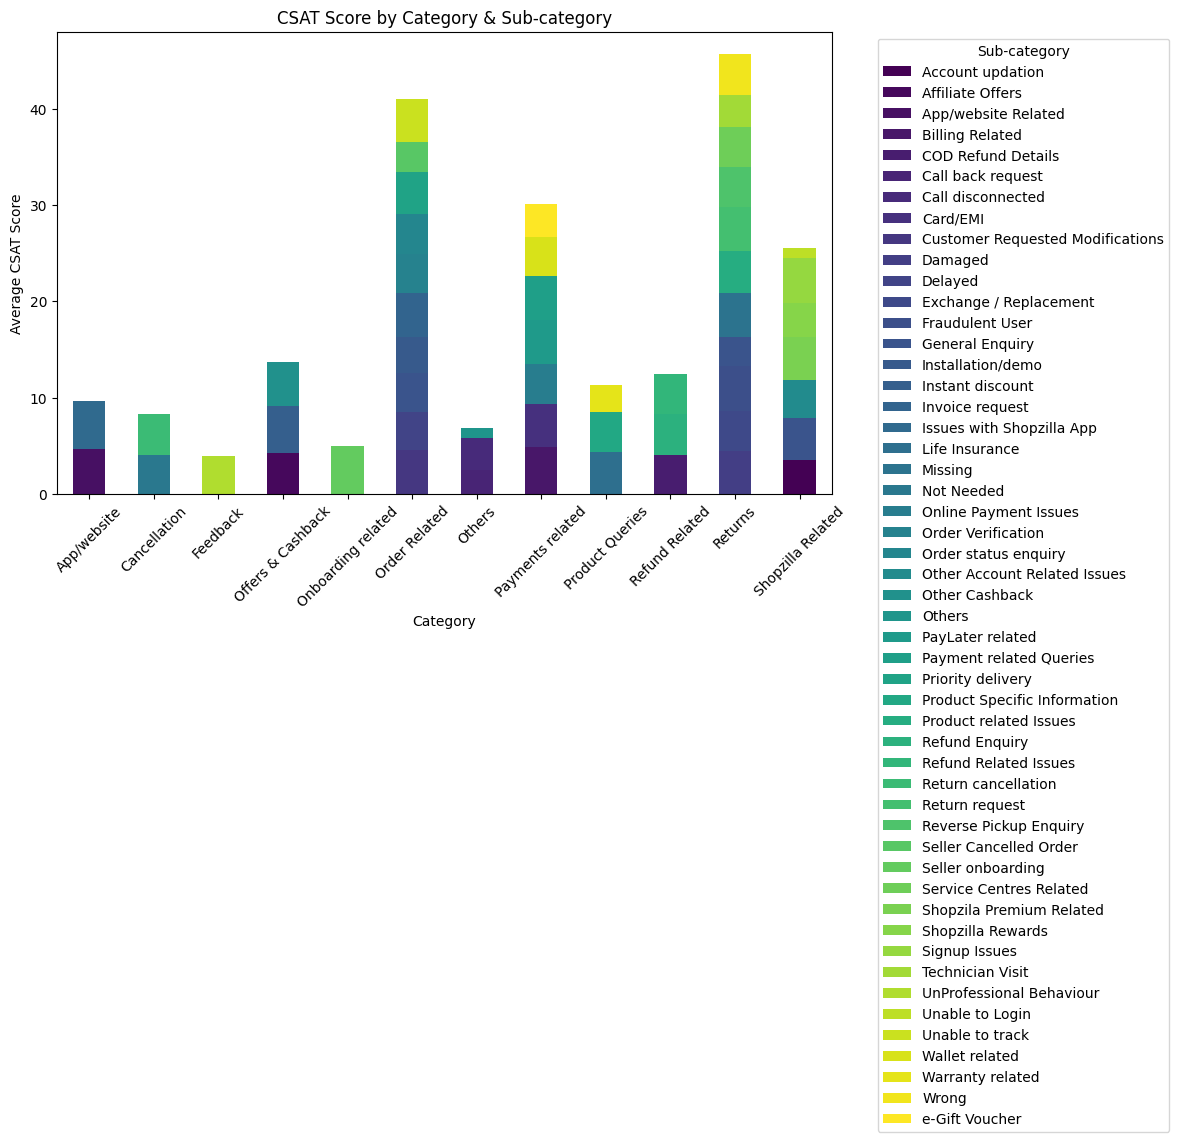

In [46]:
df_categorySub_grouped.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')

plt.xlabel('Category')
plt.ylabel('Average CSAT Score')
plt.title('CSAT Score by Category & Sub-category')

plt.legend(title='Sub-category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

This chart helps compare customer satisfaction (CSAT Score) across different issue categories and subcategories.

##### 2. What is/are the insight(s) found from the chart?

It provides insights into which types of issues are impacting customer satisfaction the most.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

If certain categories/sub-categories have consistently low CSAT Scores, they may need process improvements.
Helps businesses prioritize which issues to fix first to improve overall satisfaction.

#### Chart - 10 - CSAT Score Distribution by Agent Shift

<ipython-input-47-b5fe5367fcae>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Agent Shift'], y=df['CSAT Score'], palette='coolwarm')


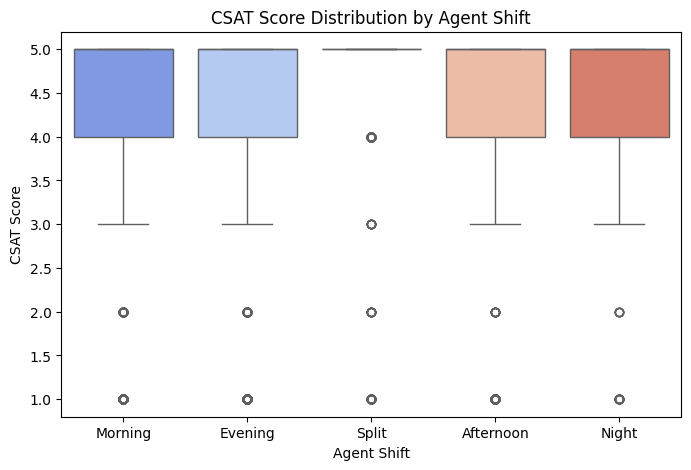

In [47]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df['Agent Shift'], y=df['CSAT Score'], palette='coolwarm')

plt.xlabel('Agent Shift')
plt.ylabel('CSAT Score')
plt.title('CSAT Score Distribution by Agent Shift')

plt.show()

##### 1. Why did you pick the specific chart?

This chart helps to analyse, how CSAT Score varies across different agent shifts (e.g., morning, evening, night).

##### 2. What is/are the insight(s) found from the chart?

It provides insights into potential performance differences among shifts and helps identify areas for improvement.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

If one shift has consistently lower CSAT Scores, it means, Lack of experienced agents, Higher workload during that shift, Poor issue resolution quality, If another shift performs better, businesses can replicate best practices from that shift.

## **4. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

1. Improve Response Time
Objective: Reduce time gaps between issue reported and issue responded.

Implement Service Level Agreements (SLAs) to ensure timely responses to customer inquiries.

2. Focus on High-Impact Categories/Sub-categories
Objective: Identify and improve areas of service that consistently result in low CSAT scores.

Deep-dive into specific categories and subcategories that show low CSAT scores. For example, if “delivery issues” consistently have low ratings, improve the delivery process, optimize logistics, and address any recurring customer pain points.

3. Implement Customer Feedback Loops
Objective: Gain better insights into customer sentiment and continuously improve customer service.
Use post-interaction surveys or follow-up calls to capture feedback about the issue resolution process. This will help identify areas that need immediate attention and provide a platform for customers to voice concerns.

4. Set Clear Performance Benchmarks and KPIs
Objective: Establish clear metrics to measure and track success in achieving higher CSAT scores.

Set specific, measurable, attainable, relevant, and time-bound (SMART) goals for CSAT improvements across the company (e.g., reducing the average response time by 20%, improving CSAT score by 10% in the next quarter).

# **Conclusion**

The analysis of CSAT Score across different aspects of the customer service process reveals several key insights that can significantly inform service improvements.
These are following improvement:
CSAT Score and Time Difference
The scatter chart highlighting the relationship between Time Difference (response time) and CSAT Score shows a clear trend that longer response times correlate with lower CSAT scores. This emphasizes the importance of timely issue resolution in maintaining high customer satisfaction.
CSAT Score by Category & Sub-category
Categories and subcategories with consistently low CSAT scores can be targeted for process improvements. Identifying such trends can help in prioritizing improvements in specific areas to boost overall customer satisfaction.
CSAT Score Distribution by Agent Shift
If certain shifts show consistently lower CSAT scores, it suggests that there might be issues related to staffing, training, or workload management during those times.
Addressing these factors, such as offering additional training or optimizing shift schedules, could improve performance during lower-scoring shifts.

Implement changes in how issues are handled, particularly focusing on fast response times without compromising issue resolution quality.
Provide additional training to agents working during shifts with lower CSAT scores, ensuring they have the tools and knowledge to improve customer satisfaction.
Regularly monitor these metrics to track progress and ensure continuous improvement in customer service.